## Setup

### Import Libraries

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.utils.data import random_split

import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

### Set Seed

In [ ]:
SEED = 42
torch.manual_seed(SEED)

### Prepare Data

#### Create Custom Data Class for Wine Dataset

In [ ]:
class WineDataset(Dataset):
    def __init__(self):
        # load data
        df = pd.read_csv('data/raw/wine.csv')

        self.features = torch.tensor(df.drop(columns = 'Wine').values, dtype=torch.float32)
        self.labels = torch.tensor(df['Wine'].values, dtype = torch.long) - 1 # subtract 1 to start at 0

    def __len__(self):
        '''Get the number of samples in the dataset'''
        return len(self.labels)
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

## Section 1: Normalize Data


| Code | Description |
|---|---|
| `StandardScaler().fit_transform(data)` | Scales the data by standardizing it. It subtracts the mean and divides by the standard deviation. |
| `RobustScaler().fit_transform(data)` | Scales the data using median and interquartile range. Reduces effect of outliers. |
| `MinMaxScaler().fit_transform(data)` | Scales the data using the range between the minimum and maximum value. |

#### **Exercises**


In [ ]:
wine = WineDataset()

features_unscaled = wine.features.numpy()

features_unscaled

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13), dtype=float32)

**Example**: Scale the features (extracted and assigned to `features_unscaled` above) in the wine dataset by standardizing it. Update the features attribute of the wine dataset with the scaled data.

Compare the values of the scaled features to the unscaled features displayed above. Do they look the way you would expect for standardized data?

In [ ]:
wine.features = torch.tensor(StandardScaler().fit_transform(features_unscaled), dtype=torch.float32)
wine.features

tensor([[ 1.5186, -0.5622,  0.2321,  ...,  0.3622,  1.8479,  1.0130],
        [ 0.2463, -0.4994, -0.8280,  ...,  0.4061,  1.1134,  0.9652],
        [ 0.1969,  0.0212,  1.1093,  ...,  0.3183,  0.7886,  1.3951],
        ...,
        [ 0.3328,  1.7447, -0.3894,  ..., -1.6121, -1.4854,  0.2806],
        [ 0.2092,  0.2277,  0.0127,  ..., -1.5683, -1.4007,  0.2965],
        [ 1.3951,  1.5832,  1.3652,  ..., -1.5244, -1.4289, -0.5952]])

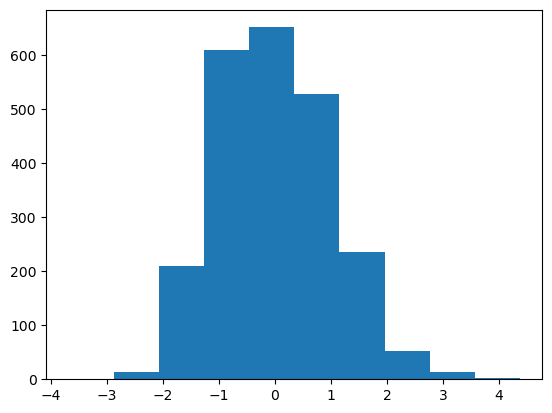

In [ ]:
plt.hist(wine.features.flatten());

**Exercise**: Scale the features (`features_unscaled`) in the wine dataset with the `RobustScaler()` it. Update the features attribute of the wine dataset with the scaled data.

In [ ]:
wine.features = torch.tensor(RobustScaler().fit_transform(features_unscaled), dtype=torch.float32)
wine.features

tensor([[ 0.8973, -0.1047,  0.2014,  ...,  0.2222,  0.9249,  0.8080],
        [ 0.1141, -0.0574, -0.6331,  ...,  0.2519,  0.5030,  0.7771],
        [ 0.0836,  0.3345,  0.8921,  ...,  0.1926,  0.3164,  1.0557],
        ...,
        [ 0.1673,  1.6318, -0.2878,  ..., -1.1111, -0.9899,  0.3333],
        [ 0.0913,  0.4899,  0.0288,  ..., -1.0815, -0.9412,  0.3437],
        [ 0.8213,  1.5101,  1.0935,  ..., -1.0519, -0.9574, -0.2343]])

**Exercise**: Scale the features (`features_unscaled`) in the wine dataset with the `MinMaxScaler()` it. Update the features attribute of the wine dataset with the scaled data.

Compare the values of the scaled features to the unscaled features displayed above. Do they look the way you would expect for data normalized by the range between the min and max value?

In [ ]:
wine.features = torch.tensor(MinMaxScaler().fit_transform(features_unscaled), dtype=torch.float32)
wine.features

tensor([[0.8421, 0.1917, 0.5722,  ..., 0.4553, 0.9707, 0.5613],
        [0.5711, 0.2055, 0.4171,  ..., 0.4634, 0.7802, 0.5506],
        [0.5605, 0.3202, 0.7005,  ..., 0.4472, 0.6960, 0.6469],
        ...,
        [0.5895, 0.6996, 0.4813,  ..., 0.0894, 0.1062, 0.3973],
        [0.5632, 0.3656, 0.5401,  ..., 0.0976, 0.1282, 0.4009],
        [0.8158, 0.6640, 0.7380,  ..., 0.1057, 0.1209, 0.2011]])